In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar que Python encuentra la carpeta 'src/' desde la carpeta 'notebooks/'
sys.path.append(str(Path("../").resolve()))

# Importar SOLO la función de procesamiento principal
from src.filtering import process_all_jv_curves

# Configuración estética
sns.set_theme(style="whitegrid")

# ==============================================================
# 2. CARGA DE DATOS BRUTOS EN MEMORIA (NO SE MODIFICAN)
# ==============================================================
PROCESSED_DIR = Path("../data/processed/outdoor")
device_dirs = [d.name for d in PROCESSED_DIR.iterdir() if d.is_dir()]
raw_data_dict = {}

for name in device_dirs:
    parquet_path = PROCESSED_DIR / name / f"{name}_jv.parquet"
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        if not df.empty:
            raw_data_dict[name] = df

print(f"✅ Cargados los datasets en bruto de {len(raw_data_dict)} celdas.")

✅ Cargados los datasets en bruto de 8 celdas.


In [2]:
# ==============================================================
# DEFINICIÓN DE LA FUNCIÓN VISUAL EN EL NOTEBOOK
# ==============================================================
def visualize_filter_discards_exclusive(jv_df: pd.DataFrame, filter_col: str, all_filters: list, n_rows: int = 3, n_cols: int = 3):
    """
    Busca y grafica las curvas que fueron descartadas EXCLUSIVAMENTE por un filtro específico
    (es decir, pasaron todos los demás filtros sin problema).
    """
    # 1. ESTE filtro debe haber fallado (True/1)
    target_fail = jv_df[filter_col].fillna(0).astype(bool)

    # 2. TODOS LOS DEMÁS filtros deben haber pasado (False/0)
    other_filters = [f for f in all_filters if f != filter_col]
    others_pass = (jv_df[other_filters].fillna(0) == 0).all(axis=1)

    # 3. La curva de error real es la intersección
    error_mask = target_fail & others_pass
    error_curves = jv_df[error_mask]['id_curve'].unique()

    if len(error_curves) == 0:
        print(f"✅ Ninguna curva fue descartada *exclusivamente* por '{filter_col}'.")
        return

    # 4. Seleccionar curvas aleatorias
    n_samples = min(len(error_curves), n_rows * n_cols)
    sampled_curves = np.random.choice(error_curves, n_samples, replace=False)

    # 5. Preparar la figura
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
    fig.suptitle(
        f'Descartadas EXCLUSIVAMENTE por: {filter_col}\n(Total exclusivas: {len(error_curves)})',
        fontsize=16, fontweight='bold', y=1.02
    )
    axes = axes.flatten()

    # 6. Graficar cada curva
    for i, curve_id in enumerate(sampled_curves):
        ax = axes[i]
        curve_data = jv_df[jv_df['id_curve'] == curve_id]
        cell_name = curve_data['cell_name'].iloc[0]

        fwd = curve_data[curve_data['is_reverse'] == 0].sort_values('Voltage_V')
        rev = curve_data[curve_data['is_reverse'] == 1].sort_values('Voltage_V')

        if not fwd.empty:
            ax.plot(fwd['Voltage_V'] * 1000, fwd['Current_A'] * 1000,
                    label='Forward', color='tab:red', linestyle='-', alpha=0.9)
        if not rev.empty:
            ax.plot(rev['Voltage_V'] * 1000, rev['Current_A'] * 1000,
                    label='Reverse', color='orange', linestyle='--', alpha=0.9)

        ax.set_title(f'ID: {curve_id} | {cell_name}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Voltage (mV)', fontsize=10)
        ax.set_ylabel('Current (mA)', fontsize=10)
        ax.grid(True, linestyle='-', alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=9)

        if i == 0:
            ax.legend(loc='best', fontsize=9)

    # Ocultar los subplots sobrantes si hay menos curvas que espacios
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [9]:
# ==============================================================
# EXPERIMENTACIÓN Y AJUSTE (DATASET DE PRUEBA)
# ==============================================================
# Modifica los umbrales aquí y ejecuta la celda para ver cómo cambian las gráficas:
jv_test = process_all_jv_curves(
    raw_dfs_dict=raw_data_dict,
    v_span_threshold_mv=50,      # Mantenemos esto bajo para rescatar celdas degradadas
    i_span_threshold_A=0.0001,   # Mantenemos esto bajo
    freeze_run_threshold=15,     
    spike_tol=2,                 # Máximo 2 puntos anómalos permitidos por curva
    noise_tol=2.5                # Tolerancia estricta a oscilaciones  
)

# ==============================================================
# VISUALIZACIÓN INTERACTIVA
# ==============================================================
# 'is_short_curve' ha sido eliminado de esta lista para coincidir con tu src/filtering.py
filters_to_review = [
    'is_low_voltage', 'is_low_current', 'is_night_time', 
    'is_curve_frozen', 'is_corrupted', 'is_spike_error', 'is_contact_noise',
    'is_asymmetric', 'is_mean_mismatch'
]

# Cambia el nombre del filtro aquí para auditar uno u otro:
TARGET_FILTER = 'is_contact_noise'

print(f"\nGenerando gráficas para el filtro: {TARGET_FILTER}")
visualize_filter_discards_exclusive(
    jv_df=jv_test, 
    filter_col=TARGET_FILTER, 
    all_filters=filters_to_review
)

TypeError: process_all_jv_curves() got an unexpected keyword argument 'spike_tol'


Generando auditoría visual de curvas VÁLIDAS...


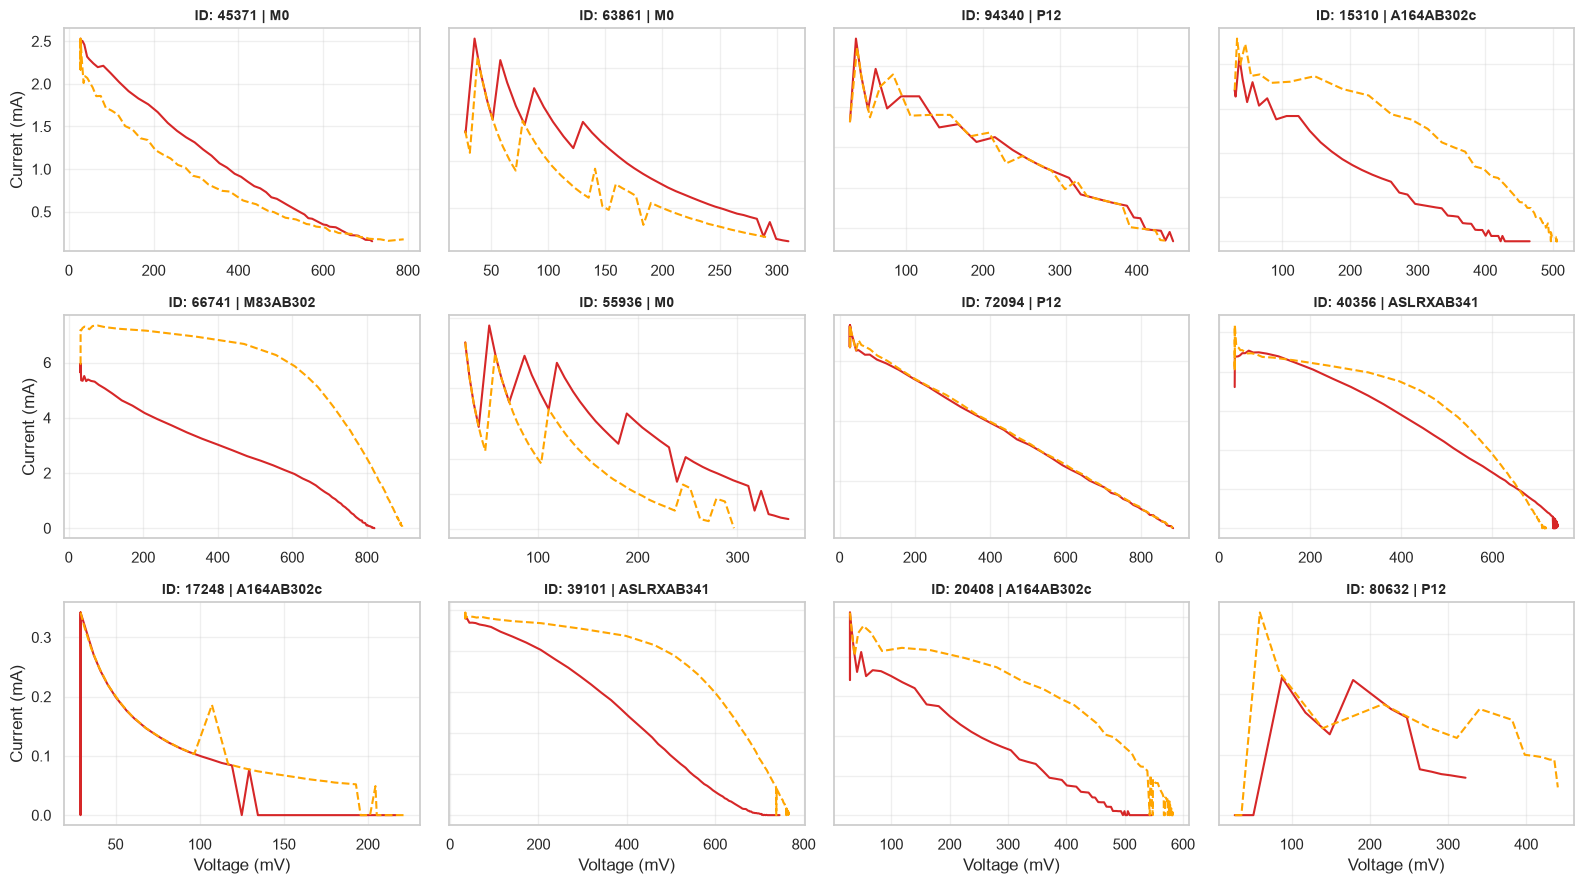

In [8]:
# ==============================================================
# AUDITORÍA VISUAL DEL DATASET LIMPIO
# ==============================================================
def audit_valid_dataset(jv: pd.DataFrame, num_samples: int = 12):
    """
    Selecciona aleatoriamente curvas VÁLIDAS y las muestra en una cuadrícula
    para realizar una auditoría visual rápida del dataset filtrado.
    """
    # Aislar solo las curvas que pasaron el filtro
    valid_jv = jv[jv['is_curve_valid'] == 1]
    valid_ids = valid_jv['id_curve'].unique()

    if len(valid_ids) == 0:
        print("⚠️ No hay curvas válidas para auditar.")
        return

    # Elegir IDs al azar
    sample_ids = np.random.choice(valid_ids, size=min(num_samples, len(valid_ids)), replace=False)

    # Configurar la cuadrícula (4 columnas)
    cols = 4
    rows = (len(sample_ids) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    
    # Manejar el caso de que solo haya 1 fila (axes no sería un array 2D)
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, cid in enumerate(sample_ids):
        ax = axes[i]
        curve = valid_jv[valid_jv['id_curve'] == cid]
        cell_name = curve['cell_name'].iloc[0]

        # Separar y ordenar Fwd y Rev para graficar la Corriente
        fwd = curve[curve['is_reverse'] == 0].sort_values('Voltage_V')
        rev = curve[curve['is_reverse'] == 1].sort_values('Voltage_V')

        if not fwd.empty:
            ax.plot(fwd['Voltage_V'] * 1000, fwd['Current_A'] * 1000, color='tab:red', label='Fwd')
        if not rev.empty:
            ax.plot(rev['Voltage_V'] * 1000, rev['Current_A'] * 1000, color='orange', linestyle='--', label='Rev')

        ax.set_title(f"ID: {cid} | {cell_name}", fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Limpiar ejes para que la cuadrícula se vea limpia
        if i % cols == 0:
            ax.set_ylabel('Current (mA)')
        else:
            ax.set_yticklabels([])

        if i >= len(sample_ids) - cols:
            ax.set_xlabel('Voltage (mV)')

    # Ocultar los subplots sobrantes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# Ejecutar la auditoría sobre el dataset de prueba interactivo
print("\nGenerando auditoría visual de curvas VÁLIDAS...")
audit_valid_dataset(jv_test, num_samples=12)